In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print(trades.shape)
print(sentiment.shape)

(88467, 16)
(2644, 4)


/tmp/ipykernel_2955/3526668914.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("historical_data.csv")


In [15]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['Timestamp IST'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [5]:
print(trades.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [6]:
merged = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

print(merged.shape)
merged.head()

(88467, 18)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [7]:
result = merged.groupby('classification')['Closed PnL'].mean().reset_index()

print(result)

  classification  Closed PnL
0   Extreme Fear   76.680902
1  Extreme Greed  121.900517
2           Fear   81.463878
3          Greed   77.679216
4        Neutral   71.859323


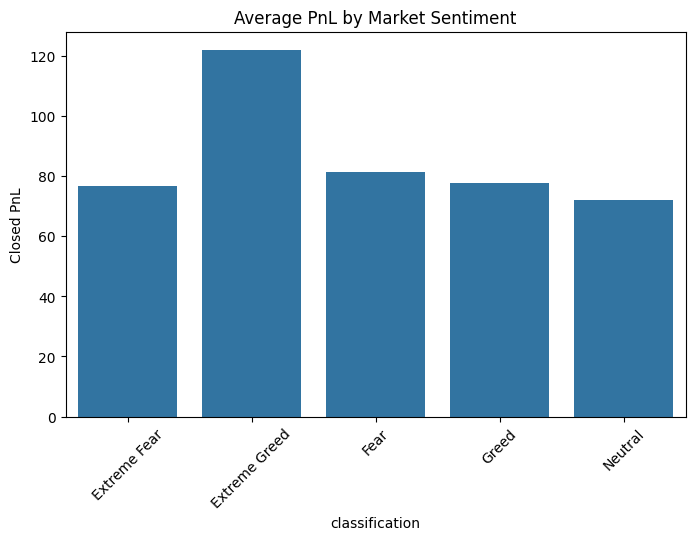

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=result,
    x='classification',
    y='Closed PnL'
)
plt.title('Average PnL by Market Sentiment')
plt.xticks(rotation=45)
plt.show()

In [9]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('classification')['win'].mean()*100

print(win_rate)

classification
Extreme Fear     37.067922
Extreme Greed    51.058890
Fear             45.976449
Greed            40.724251
Neutral          46.565460
Name: win, dtype: float64


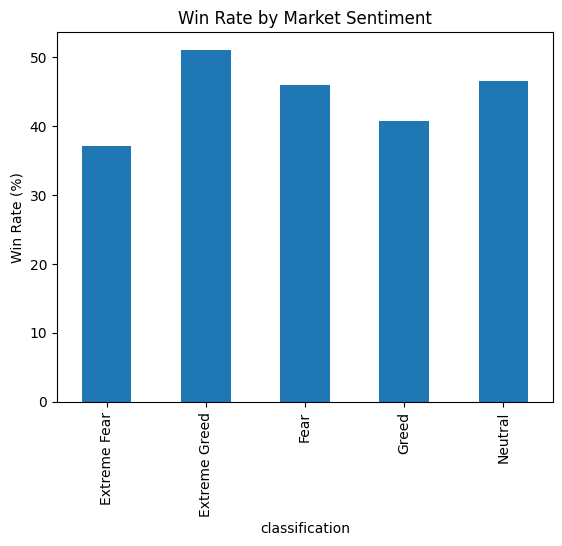

In [10]:
win_rate.plot(kind='bar')
plt.title('Win Rate by Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.show()

In [11]:
side_analysis = merged.groupby(
    ['classification', 'Side']
)['Closed PnL'].mean().reset_index()

print(side_analysis)

  classification  Side  Closed PnL
0   Extreme Fear   BUY   71.808992
1   Extreme Fear  SELL   83.142738
2  Extreme Greed   BUY   21.268160
3  Extreme Greed  SELL  210.986649
4           Fear   BUY   97.865214
5           Fear  SELL   65.519395
6          Greed   BUY   58.595557
7          Greed  SELL   94.393355
8        Neutral   BUY   75.254781
9        Neutral  SELL   68.268849


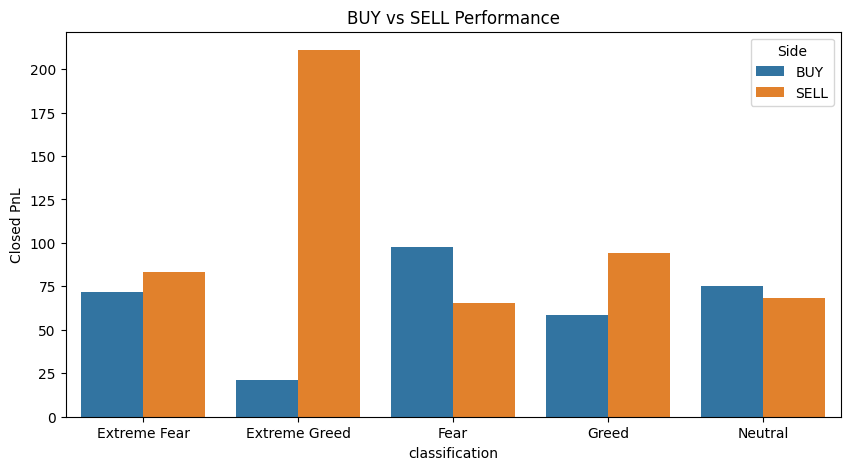

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=side_analysis,
    x='classification',
    y='Closed PnL',
    hue='Side'
)
plt.title('BUY vs SELL Performance')
plt.show()

In [13]:
volume = merged.groupby(
    'classification'
)['Size USD'].sum().reset_index()

print(volume)

  classification      Size USD
0   Extreme Fear  3.915873e+07
1  Extreme Greed  8.473151e+07
2           Fear  3.310223e+08
3          Greed  2.264780e+08
4        Neutral  1.277166e+08


In [14]:
top_traders = merged.groupby(
    'Account'
)['Closed PnL'].sum().sort_values(
    ascending=False
).head(10)

print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760    3.089759e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641    1.995056e+05
0x6d6a4b953f202f8df5bed40692e7fd865318264a    1.087312e+05
Name: Closed PnL, dtype: float64
